In [1]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]

Python executable:
/home/gajapathimugunda/genai-learning/.venv/bin/python


In [6]:
import tiktoken
import numpy
import sklearn
import matplotlib
import sentence_transformers
import torch

print("GenAI environment is ready!")
print("PyTorch:", torch.__version__)
print("Sentence Transformers:", sentence_transformers.__version__)

GenAI environment is ready!
PyTorch: 2.14.0+cu130
Sentence Transformers: 6.1.0


In [7]:
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

text = "Artificial Intelligence is changing the world."

tokens = encoding.encode(text)

print("Text:")
print(text)

print("\nToken IDs:")
print(tokens)

print("\nNumber of tokens:")
print(len(tokens))

Text:
Artificial Intelligence is changing the world.

Token IDs:
[9470, 16895, 22107, 374, 10223, 279, 1917, 13]

Number of tokens:
8


In [8]:
token_pieces = [encoding.decode_single_token_bytes(token).decode("utf-8", errors="replace")
                for token in tokens]

for token_id, token_piece in zip(tokens, token_pieces):
    print(token_id, "→", repr(token_piece))

9470 → 'Art'
16895 → 'ificial'
22107 → ' Intelligence'
374 → ' is'
10223 → ' changing'
279 → ' the'
1917 → ' world'
13 → '.'


In [9]:
decoded_text = encoding.decode(tokens)

print(decoded_text)

Artificial Intelligence is changing the world.


In [10]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded!


In [11]:
text = "I love programming."

embedding = model.encode(text)

print("Embedding:")
print(embedding)

print("\nNumber of dimensions:")
print(len(embedding))

Embedding:
[-1.96318887e-02 -1.78364050e-02  1.01795113e-02 -1.56989079e-02
  9.75868315e-05 -6.95641786e-02  6.62220418e-02  6.28248453e-02
  1.87697541e-02  4.82450984e-02 -8.42706710e-02  4.36685011e-02
  3.02407574e-02  7.12940563e-03  3.28506343e-02 -2.44301334e-02
 -7.92887211e-02 -5.10528348e-02  3.34562780e-03 -6.60609230e-02
 -1.31806687e-01 -7.15702074e-03 -2.76183821e-02 -3.47109623e-02
  6.26970157e-02  1.01214133e-01 -5.51319961e-03 -5.24691343e-02
  1.58608623e-03 -7.05859512e-02 -1.00390561e-01  1.16564095e-01
  6.45660535e-02  5.97039573e-02  1.41535522e-02  5.56601100e-02
  8.15810561e-02 -6.38456866e-02  1.53268443e-03  7.92236160e-03
 -9.66392159e-02  5.61903827e-02  3.98315080e-02 -2.49242485e-02
 -9.59009491e-03 -5.08046113e-02 -2.76329573e-02 -5.16978391e-02
  7.54264742e-02  2.26114839e-02  7.19173485e-03 -1.23919537e-02
 -1.04391089e-04 -3.66736352e-02 -1.23290776e-03 -1.14938030e-02
  7.88573176e-02  1.09366607e-02 -2.11204942e-02 -3.26129086e-02
 -5.19716740e-

In [12]:
text1 = "I love programming."
text2 = "I enjoy coding."

embedding1 = model.encode(text1)
embedding2 = model.encode(text2)

print("Vector 1 dimensions:", len(embedding1))
print("Vector 2 dimensions:", len(embedding2))

Vector 1 dimensions: 384
Vector 2 dimensions: 384


In [13]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(
    [embedding1],
    [embedding2]
)

print("Similarity:", similarity[0][0])

Similarity: 0.82872933


In [14]:
text3 = "The weather is rainy today."

embedding3 = model.encode(text3)

similarity2 = cosine_similarity(
    [embedding1],
    [embedding3]
)

print("Similarity:", similarity2[0][0])

Similarity: -0.030221567


In [15]:
sentences = [
    "I love programming.",
    "I enjoy coding.",
    "The weather is rainy today."
]

embeddings = model.encode(sentences)

similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[ 1.0000002   0.8287292  -0.03022152]
 [ 0.8287292   0.99999994 -0.0317345 ]
 [-0.03022152 -0.0317345   1.0000002 ]]


In [16]:
documents = [
    "Python is a popular programming language.",
    "Docker packages applications into containers.",
    "PostgreSQL is a relational database.",
    "Machine learning allows computers to learn from data.",
    "The weather forecast predicts heavy rain tomorrow."
]

document_embeddings = model.encode(documents)

In [17]:
query = "How can I learn programming?"

In [18]:
query_embedding = model.encode([query])

In [19]:
scores = cosine_similarity(
    query_embedding,
    document_embeddings
)[0]

for document, score in zip(documents, scores):
    print(f"{score:.4f} → {document}")

0.4211 → Python is a popular programming language.
-0.0127 → Docker packages applications into containers.
0.1329 → PostgreSQL is a relational database.
0.2719 → Machine learning allows computers to learn from data.
0.0440 → The weather forecast predicts heavy rain tomorrow.


In [20]:
best_index = scores.argmax()

print("Query:")
print(query)

print("\nMost relevant document:")
print(documents[best_index])

print("\nSimilarity:")
print(scores[best_index])

Query:
How can I learn programming?

Most relevant document:
Python is a popular programming language.

Similarity:
0.4210527


In [21]:
document_text = """
Docker is a platform used to package applications and their dependencies
into lightweight containers.

Docker containers provide consistency across development, testing, and
production environments.

Docker Compose is used to define and run multi-container applications.
It allows developers to configure services, networks, and volumes using
a YAML file.

PostgreSQL is an open-source relational database system. It supports
SQL and provides features such as transactions, indexes, and constraints.
"""

with open("technology.txt", "w") as file:
    file.write(document_text)

print("Document created!")

Document created!


In [22]:
with open("technology.txt", "r") as file:
    text = file.read()

print(text)


Docker is a platform used to package applications and their dependencies
into lightweight containers.

Docker containers provide consistency across development, testing, and
production environments.

Docker Compose is used to define and run multi-container applications.
It allows developers to configure services, networks, and volumes using
a YAML file.

PostgreSQL is an open-source relational database system. It supports
SQL and provides features such as transactions, indexes, and constraints.



In [23]:
chunk_size = 200

chunks = []

for i in range(0, len(text), chunk_size):
    chunk = text[i:i + chunk_size]
    chunks.append(chunk)

print("Number of chunks:", len(chunks))

Number of chunks: 3


In [24]:
for i, chunk in enumerate(chunks):
    print(f"\n--- Chunk {i} ---")
    print(chunk)


--- Chunk 0 ---

Docker is a platform used to package applications and their dependencies
into lightweight containers.

Docker containers provide consistency across development, testing, and
production environments.


--- Chunk 1 ---

Docker Compose is used to define and run multi-container applications.
It allows developers to configure services, networks, and volumes using
a YAML file.

PostgreSQL is an open-source relational da

--- Chunk 2 ---
tabase system. It supports
SQL and provides features such as transactions, indexes, and constraints.



In [25]:
import re

sentences = re.split(r'(?<=[.!?])\s+', text.strip())

for i, sentence in enumerate(sentences):
    print(f"{i}: {sentence}")

0: Docker is a platform used to package applications and their dependencies
into lightweight containers.
1: Docker containers provide consistency across development, testing, and
production environments.
2: Docker Compose is used to define and run multi-container applications.
3: It allows developers to configure services, networks, and volumes using
a YAML file.
4: PostgreSQL is an open-source relational database system.
5: It supports
SQL and provides features such as transactions, indexes, and constraints.


In [26]:
chunks = []

current_chunk = ""

for sentence in sentences:
    if len(current_chunk) + len(sentence) <= 200:
        current_chunk += " " + sentence
    else:
        chunks.append(current_chunk.strip())
        current_chunk = sentence

if current_chunk:
    chunks.append(current_chunk.strip())

for i, chunk in enumerate(chunks):
    print(f"\n--- Chunk {i} ---")
    print(chunk)


--- Chunk 0 ---
Docker is a platform used to package applications and their dependencies
into lightweight containers. Docker containers provide consistency across development, testing, and
production environments.

--- Chunk 1 ---
Docker Compose is used to define and run multi-container applications. It allows developers to configure services, networks, and volumes using
a YAML file.

--- Chunk 2 ---
PostgreSQL is an open-source relational database system. It supports
SQL and provides features such as transactions, indexes, and constraints.


In [27]:
chunks

['Docker is a platform used to package applications and their dependencies\ninto lightweight containers. Docker containers provide consistency across development, testing, and\nproduction environments.',
 'Docker Compose is used to define and run multi-container applications. It allows developers to configure services, networks, and volumes using\na YAML file.',
 'PostgreSQL is an open-source relational database system. It supports\nSQL and provides features such as transactions, indexes, and constraints.']

In [28]:
print("Number of chunks:", len(chunks))

for i, chunk in enumerate(chunks):
    print(f"\nChunk {i}:")
    print(chunk)

Number of chunks: 3

Chunk 0:
Docker is a platform used to package applications and their dependencies
into lightweight containers. Docker containers provide consistency across development, testing, and
production environments.

Chunk 1:
Docker Compose is used to define and run multi-container applications. It allows developers to configure services, networks, and volumes using
a YAML file.

Chunk 2:
PostgreSQL is an open-source relational database system. It supports
SQL and provides features such as transactions, indexes, and constraints.


In [29]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [30]:
chunk_embeddings = model.encode(chunks)

print("Number of chunks:", len(chunks))
print("Embedding shape:", chunk_embeddings.shape)

Number of chunks: 3
Embedding shape: (3, 384)


In [31]:
vector_store = []

for i, (chunk, embedding) in enumerate(zip(chunks, chunk_embeddings)):
    vector_store.append({
        "id": i,
        "text": chunk,
        "embedding": embedding
    })

print("Stored:", len(vector_store), "chunks")

Stored: 3 chunks


In [32]:
print(vector_store[0])

{'id': 0, 'text': 'Docker is a platform used to package applications and their dependencies\ninto lightweight containers. Docker containers provide consistency across development, testing, and\nproduction environments.', 'embedding': array([-1.80348363e-02,  6.56876490e-02,  3.62980254e-02, -9.57494322e-03,
        6.00001588e-02, -4.75285240e-02, -9.27048456e-03,  3.27798612e-02,
        3.21886502e-02,  6.00324152e-03, -6.54113144e-02, -1.97160617e-02,
        1.88760348e-02, -2.11663786e-02,  1.08948238e-02, -5.84498122e-02,
        4.83060926e-02,  6.61000758e-02, -6.81882259e-03,  3.66507880e-02,
       -1.27993912e-01,  6.71474710e-02, -9.54763070e-02,  4.27707247e-02,
       -6.46749586e-02,  5.46241701e-02, -4.96600159e-02, -5.98055795e-02,
       -3.71020054e-04, -2.71163732e-02,  5.32864034e-02,  5.59001416e-02,
        3.86204459e-02,  1.37797249e-02, -2.41478961e-02,  9.13154110e-02,
        4.77980496e-03, -4.61514741e-02, -3.01156081e-02, -2.58820653e-02,
       -3.505847

In [33]:
query = "What is Docker Compose used for?"

In [34]:
query_embedding = model.encode([query])

In [35]:
from sklearn.metrics.pairwise import cosine_similarity

scores = cosine_similarity(
    query_embedding,
    chunk_embeddings
)[0]

for i, score in enumerate(scores):
    print(f"Chunk {i}: {score:.4f}")

Chunk 0: 0.6527
Chunk 1: 0.8763
Chunk 2: 0.2063


In [36]:
best_index = scores.argmax()

print("Query:")
print(query)

print("\nRetrieved chunk:")
print(chunks[best_index])

print("\nSimilarity score:")
print(scores[best_index])

Query:
What is Docker Compose used for?

Retrieved chunk:
Docker Compose is used to define and run multi-container applications. It allows developers to configure services, networks, and volumes using
a YAML file.

Similarity score:
0.87631047


In [37]:
top_k = 2

top_indices = scores.argsort()[::-1][:top_k]

for rank, index in enumerate(top_indices, start=1):
    print(f"\nRank {rank}")
    print("Score:", scores[index])
    print("Chunk:", chunks[index])


Rank 1
Score: 0.87631047
Chunk: Docker Compose is used to define and run multi-container applications. It allows developers to configure services, networks, and volumes using
a YAML file.

Rank 2
Score: 0.65268636
Chunk: Docker is a platform used to package applications and their dependencies
into lightweight containers. Docker containers provide consistency across development, testing, and
production environments.


In [39]:
context = "\n\n".join(
    chunks[index] for index in top_indices
)

query = "What is Docker Compose used for?"

prompt = f"""
Use the following context to answer the question.

Context:
{context}

Question:
{query}

Answer:
"""

print(prompt)


Use the following context to answer the question.

Context:
Docker Compose is used to define and run multi-container applications. It allows developers to configure services, networks, and volumes using
a YAML file.

Docker is a platform used to package applications and their dependencies
into lightweight containers. Docker containers provide consistency across development, testing, and
production environments.

Question:
What is Docker Compose used for?

Answer:



In [40]:
print("QUESTION:")
print(query)

print("\nRETRIEVED CONTEXT:")
print(context)

QUESTION:
What is Docker Compose used for?

RETRIEVED CONTEXT:
Docker Compose is used to define and run multi-container applications. It allows developers to configure services, networks, and volumes using
a YAML file.

Docker is a platform used to package applications and their dependencies
into lightweight containers. Docker containers provide consistency across development, testing, and
production environments.


In [41]:
def retrieve(query, chunks, chunk_embeddings, model, top_k=2):
    query_embedding = model.encode([query])

    scores = cosine_similarity(
        query_embedding,
        chunk_embeddings
    )[0]

    top_indices = scores.argsort()[::-1][:top_k]

    results = []

    for index in top_indices:
        results.append({
            "text": chunks[index],
            "score": scores[index]
        })

    return results

In [42]:
results = retrieve(
    "What is Docker Compose used for?",
    chunks,
    chunk_embeddings,
    model
)

for result in results:
    print("Score:", result["score"])
    print("Text:", result["text"])
    print()

Score: 0.87631047
Text: Docker Compose is used to define and run multi-container applications. It allows developers to configure services, networks, and volumes using
a YAML file.

Score: 0.65268636
Text: Docker is a platform used to package applications and their dependencies
into lightweight containers. Docker containers provide consistency across development, testing, and
production environments.



In [43]:
def create_rag_prompt(query, results):
    context = "\n\n".join(
        result["text"] for result in results
    )

    prompt = f"""
You are a helpful assistant.

Answer the question using only the provided context.

Context:
{context}

Question:
{query}

Answer:
"""

    return prompt

In [44]:
query = "What is Docker Compose used for?"

results = retrieve(
    query,
    chunks,
    chunk_embeddings,
    model
)

prompt = create_rag_prompt(query, results)

print(prompt)


You are a helpful assistant.

Answer the question using only the provided context.

Context:
Docker Compose is used to define and run multi-container applications. It allows developers to configure services, networks, and volumes using
a YAML file.

Docker is a platform used to package applications and their dependencies
into lightweight containers. Docker containers provide consistency across development, testing, and
production environments.

Question:
What is Docker Compose used for?

Answer:



In [45]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "I enjoy writing software.",
    "The weather is very rainy today.",
    "It is going to rain tomorrow.",
    "I like playing football."
]

embeddings = model.encode(sentences)

print("Shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Shape: (6, 384)


In [46]:
import numpy as np

vector = np.array(embeddings[0])

print("Vector type:", type(vector))
print("Shape:", vector.shape)
print("First 10 values:")
print(vector[:10])

Vector type: <class 'numpy.ndarray'>
Shape: (384,)
First 10 values:
[-0.05761702  0.00426225 -0.02815313  0.02519759 -0.01650561 -0.17736742
  0.00836197  0.07995731 -0.01277549  0.0309688 ]


In [47]:
vector1 = embeddings[0]
vector2 = embeddings[1]

difference = vector1 - vector2

print("Difference vector:")
print(difference[:10])

Difference vector:
[ 0.01700402  0.03156539 -0.02203858  0.01984413  0.00598439 -0.04808298
  0.00603648  0.00982668 -0.01037557  0.02671033]


In [48]:
magnitude = np.linalg.norm(vector1)

print("Vector magnitude:", magnitude)

Vector magnitude: 1.0


In [49]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[ 1.0000001   0.87764996  0.63255095 -0.02387     0.02728162  0.30709606]
 [ 0.87764996  0.9999999   0.5781274  -0.01564639  0.03424264  0.20967418]
 [ 0.63255095  0.5781274   0.99999976  0.01222992  0.01949651  0.300277  ]
 [-0.02387    -0.01564639  0.01222992  1.0000002   0.6544752  -0.01164841]
 [ 0.02728162  0.03424264  0.01949651  0.6544752   1.          0.01009962]
 [ 0.30709606  0.20967418  0.300277   -0.01164841  0.01009962  1.0000001 ]]


In [50]:
for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        score = similarity_matrix[i][j]

        print(
            f"{score:.3f} | "
            f"{sentences[i]}  ↔  {sentences[j]}"
        )

0.878 | I love programming in Python.  ↔  Python is my favorite programming language.
0.633 | I love programming in Python.  ↔  I enjoy writing software.
-0.024 | I love programming in Python.  ↔  The weather is very rainy today.
0.027 | I love programming in Python.  ↔  It is going to rain tomorrow.
0.307 | I love programming in Python.  ↔  I like playing football.
0.578 | Python is my favorite programming language.  ↔  I enjoy writing software.
-0.016 | Python is my favorite programming language.  ↔  The weather is very rainy today.
0.034 | Python is my favorite programming language.  ↔  It is going to rain tomorrow.
0.210 | Python is my favorite programming language.  ↔  I like playing football.
0.012 | I enjoy writing software.  ↔  The weather is very rainy today.
0.019 | I enjoy writing software.  ↔  It is going to rain tomorrow.
0.300 | I enjoy writing software.  ↔  I like playing football.
0.654 | The weather is very rainy today.  ↔  It is going to rain tomorrow.
-0.012 | The we

In [51]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(embeddings)

print("Original shape:", embeddings.shape)
print("Reduced shape:", embeddings_2d.shape)

Original shape: (6, 384)
Reduced shape: (6, 2)


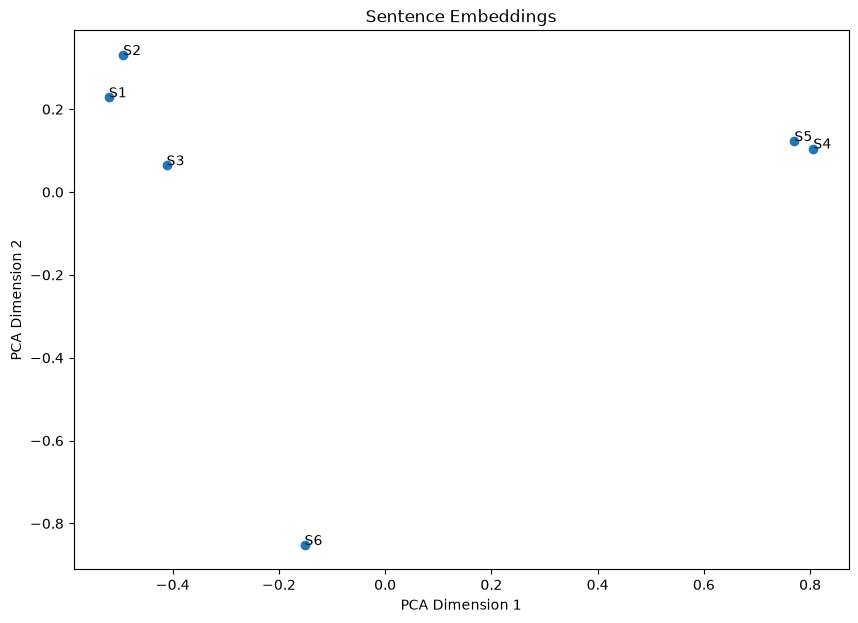

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1]
)

for i, sentence in enumerate(sentences):
    plt.annotate(
        f"S{i+1}",
        (embeddings_2d[i, 0], embeddings_2d[i, 1])
    )

plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.title("Sentence Embeddings")
plt.show()

In [53]:
for i, sentence in enumerate(sentences):
    print(f"S{i+1}: {sentence}")

S1: I love programming in Python.
S2: Python is my favorite programming language.
S3: I enjoy writing software.
S4: The weather is very rainy today.
S5: It is going to rain tomorrow.
S6: I like playing football.
